In [2]:
# ============================================================
# 1. CONFIGURACIÓN Y PARTICIÓN EXACTA DEL CONJUNTO DE PRUEBA
# ============================================================
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
import timm

# Configuración Base
SEED = 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Rutas
PROJECT_ROOT = Path.cwd().parent # Estamos asumiendo que este archivo está en Lab1/
DATASET_DIR = PROJECT_ROOT / "DATASET" 
RUTA_CNN = PROJECT_ROOT / "CNN" / "modelos" / "cnn_desde_cero.pth"
RUTA_TL = PROJECT_ROOT / "NASNetMobile" / "modelos" / "nasnet_mobile_tl.pth"

# Cargar Nombres de Clases
base_dataset = datasets.ImageFolder(DATASET_DIR)
classes = base_dataset.classes
num_classes = len(classes)

# Recrear los índices del Test Set (100% idéntico a los entrenamientos)
targets = base_dataset.targets
indices = list(range(len(targets)))

_, temp_idx, _, temp_targets = train_test_split(
    indices, targets, test_size=0.2, stratify=targets, random_state=SEED
)
_, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=temp_targets, random_state=SEED
)

print(f"Conjunto de prueba recreado con éxito: {len(test_idx)} imágenes.")

FileNotFoundError: Couldn't find any class folder in c:\Users\ASUS TUF GAMING A15\Desktop\erick\cico\2026\2-26\SIS421\Labs\Lab1\DATASET.

In [ ]:
# ============================================================
# 2. CARGA DE LAS ARQUITECTURAS Y LOS PESOS
# ============================================================

# --- A. MODELO 1: TU CNN DESDE CERO ---
def block(c_in, c_out, k=3, p=1, s=1, pk=2, ps=2):
    return nn.Sequential(
        nn.Conv2d(c_in, c_out, k, padding=p, stride=s),
        nn.ReLU(),
        nn.MaxPool2d(pk, stride=ps)
    )

class InsectCNN(nn.Module):
    def __init__(self, n_channels=3, n_outputs=num_classes):
        super().__init__()
        self.conv1 = block(n_channels, 32)
        self.conv2 = block(32, 64)
        self.conv3 = block(64, 128)
        self.conv4 = block(128, 256)
        self.fc = nn.Linear(256 * 12 * 12, n_outputs)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = x.view(x.shape[0], -1)
        x = self.fc(x)
        return x

modelo_cnn = InsectCNN(n_outputs=num_classes).to(device)
modelo_cnn.load_state_dict(torch.load(RUTA_CNN, map_location=device, weights_only=True))
modelo_cnn.eval() # Modo evaluación
print("Modelo CNN cargado correctamente.")

# --- B. MODELO 2: TRANSFER LEARNING (MnasNet o MobileNetV3) ---
# NOTA: Cambia 'mnasnet_100' por 'mobilenetv3_large_100' si usaste ese
modelo_tl = timm.create_model('mnasnet_100', pretrained=False, num_classes=num_classes).to(device)
modelo_tl.load_state_dict(torch.load(RUTA_TL, map_location=device, weights_only=True))
modelo_tl.eval() # Modo evaluación
print("Modelo de Transfer Learning cargado correctamente.")

Modelo CNN cargado correctamente.
Modelo de Transfer Learning cargado correctamente.


In [ ]:
# ============================================================
# 3. FUNCIONES DE PREDICCIÓN Y VISUALIZACIÓN LADO A LADO
# ============================================================

# Transformación para tu CNN (200x200)
transform_cnn = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transformación para Transfer Learning (224x224)
transform_tl = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def predecir_imagen(imagen_pil, modelo, transformacion):
    # Procesar imagen y pasarla a la tarjeta gráfica
    img_tensor = transformacion(imagen_pil).unsqueeze(0).to(device)
    
    with torch.no_grad():
        salida = modelo(img_tensor)
        # Aplicamos Softmax para convertir los números crudos en porcentajes de probabilidad (0 a 100%)
        probabilidades = F.softmax(salida, dim=1)
        confianza, idx_prediccion = torch.max(probabilidades, 1)
        
    clase_predicha = classes[idx_prediccion.item()]
    porcentaje = confianza.item() * 100
    return clase_predicha, porcentaje

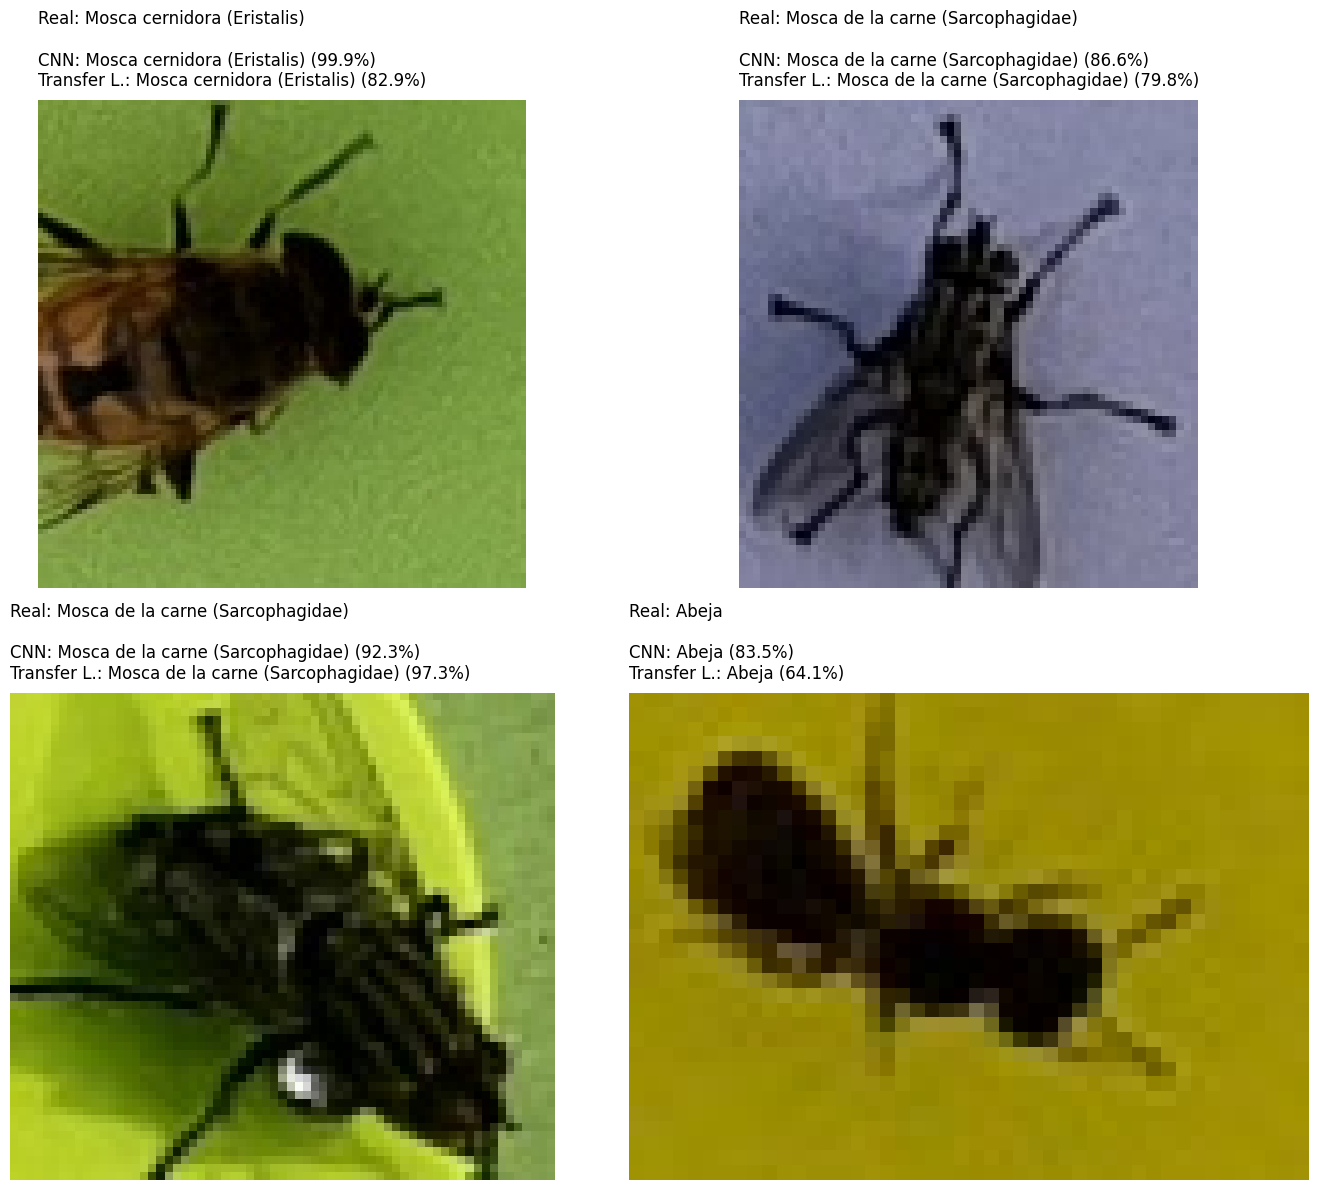

In [ ]:
# ============================================================
# 4. EL CARA A CARA: CNN vs TRANSFER LEARNING
# ============================================================

# Seleccionar 4 imágenes al azar del Test Set
indices_muestra = random.sample(test_idx, 4)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, idx in enumerate(indices_muestra):
    # Extraer imagen cruda y su etiqueta real
    ruta_img, etiqueta_real_idx = base_dataset.samples[idx]
    imagen_pil = Image.open(ruta_img).convert('RGB')
    insecto_real = classes[etiqueta_real_idx]
    
    # Obtener predicciones de ambos modelos
    pred_cnn, conf_cnn = predecir_imagen(imagen_pil, modelo_cnn, transform_cnn)
    pred_tl, conf_tl = predecir_imagen(imagen_pil, modelo_tl, transform_tl)
    
    # Lógica de colores (Verde si acierta, Rojo si falla)
    color_cnn = "green" if pred_cnn == insecto_real else "red"
    color_tl = "green" if pred_tl == insecto_real else "red"
    
    # Formatear el texto a mostrar
    texto_titulo = f"Real: {insecto_real}\n\n"
    texto_titulo += f"CNN: {pred_cnn} ({conf_cnn:.1f}%)\n"
    texto_titulo += f"Transfer L.: {pred_tl} ({conf_tl:.1f}%)"
    
    # Mostrar la imagen
    axes[i].imshow(imagen_pil)
    axes[i].set_title(texto_titulo, fontsize=12, loc='left', pad=10)
    axes[i].axis('off')
    
    # Colorear el borde de la imagen basado en si el Transfer Learning acertó o no
    if pred_tl == insecto_real:
        axes[i].spines['bottom'].set_color('green')
        axes[i].spines['top'].set_color('green')
        axes[i].spines['right'].set_color('green')
        axes[i].spines['left'].set_color('green')
        axes[i].spines['bottom'].set_linewidth(3)

plt.tight_layout()
plt.show()